# VoiceGuard — Results

Prosodic fingerprinting MVP: One-Class SVM anomaly detector trained per-speaker on genuine enrollment clips.
See `CLAUDE.md` for the full task board and current status.

**Status at time of writing**: genuine data collected and processed for two speakers (`krishiv`, `mary`, 10 clips each). Synthetic TTS clones (Stage 1) are not yet available — no API key — so this notebook currently shows genuine-only diagnostics (feature distributions, leave-one-out self-consistency). The real evaluation section (ROC-AUC, EER) is wired up and will run as soon as synthetic clips land in `data/synthetic/<speaker>/<tts_system>/` and `python src/features.py` is re-run.

In [1]:
import json
import sys

sys.path.insert(0, "../src")
sys.path.insert(0, "../src/models")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eval import evaluate
from oneclass import leave_one_out_eval

df = pd.read_csv("../data/features/features.csv")
with open("../data/features/f0_reference.json") as f:
    f0_refs = json.load(f)

df

Matplotlib is building the font cache; this may take a moment.


,speaker,clip_id,label,tts_system,f0_mean,f0_std,energy_mean,energy_std,speaking_rate_mean,pause_count,pause_mean_dur,pause_var_dur,npvi,jitter,shimmer
0,krishiv,Munpalle 13,genuine,na,-1.282192,1.979369,0.085098,0.051691,7.863144,0,0.000,0.000000,109.888357,0.031844,0.144848
1,krishiv,Munpalle 14,genuine,na,9.133766,2.405276,0.071874,0.068930,6.606607,1,0.060,0.000000,104.172217,0.026287,0.083500
2,krishiv,Munpalle 15,genuine,na,-1.560000,2.093933,0.078734,0.061486,5.859330,0,0.000,0.000000,117.187477,0.034486,0.162644
3,krishiv,Munpalle 16,genuine,na,0.499029,1.748980,0.075593,0.065133,6.708653,0,0.000,0.000000,98.885065,0.042043,0.166633
4,krishiv,Munpalle 17,genuine,na,0.493814,2.793136,0.085189,0.051768,7.355865,0,0.000,0.000000,121.881618,0.031826,0.141891
5,krishiv,Munpalle 18,genuine,na,-1.861607,2.365913,0.085847,0.051025,8.563622,0,0.000,0.000000,99.964495,0.034326,0.157659
6,krishiv,Munpalle 19,genuine,na,-1.135922,1.826177,0.081009,0.058268,5.670341,0,0.000,0.000000,112.754587,0.027649,0.140054
7,krishiv,Munpalle 20,genuine,na,-0.347619,2.941229,0.077803,0.062614,8.131114,0,0.000,0.000000,108.489315,0.037625,0.142716
8,krishiv,Munpalle 21,genuine,na,2.232222,1.729665,0.081709,0.057128,7.683215,0,0.000,0.000000,115.197783,0.033741,0.142443
9,krishiv,Munpalle 22,genuine,na,11.269333,1.966518,0.075174,0.065625,8.148148,1,0.060,0.000000,95.194662,0.019505,0.099475


## Feature distributions per speaker

Sanity check that the two speakers' prosodic fingerprints actually differ — if they didn't, the detector would have nothing to key off.

In [2]:
numeric_cols = [
    "f0_mean", "f0_std", "energy_mean", "energy_std", "speaking_rate_mean",
    "pause_count", "pause_mean_dur", "pause_var_dur", "npvi", "jitter", "shimmer",
]

genuine = df[df["label"] == "genuine"]
genuine.groupby("speaker")[numeric_cols].agg(["mean", "std"])

f0_mean              f0_std           energy_mean            \
             mean       std      mean       std        mean       std   
speaker                                                                 
krishiv  1.744083  4.648003  2.185020  0.427846    0.079803  0.004782   
mary    -1.241450  4.309346  2.388895  1.162643    0.077897  0.002721   

        energy_std           speaking_rate_mean            ... pause_mean_dur  \
              mean       std               mean       std  ...           mean   
speaker                                                    ...                  
krishiv   0.059367  0.006424           7.259004  1.001052  ...         0.0120   
mary      0.062146  0.003402           7.237881  1.167692  ...         0.0615   

                  pause_var_dur                  npvi              jitter  \
              std          mean       std        mean       std      mean   
speaker                                                                     
krishiv  0.025298      0.000000  0.000000  108.361558  8.694195  0.031933   
mary     0.085572      0.000292  0.000671  107.557430  4.243700  0.020983   

                    shimmer            
              std      mean       std  
speaker                                
krishiv  0.006279  0.138186  0.026617  
mary     0.005335  0.107903  0.019659  

[2 rows x 22 columns]

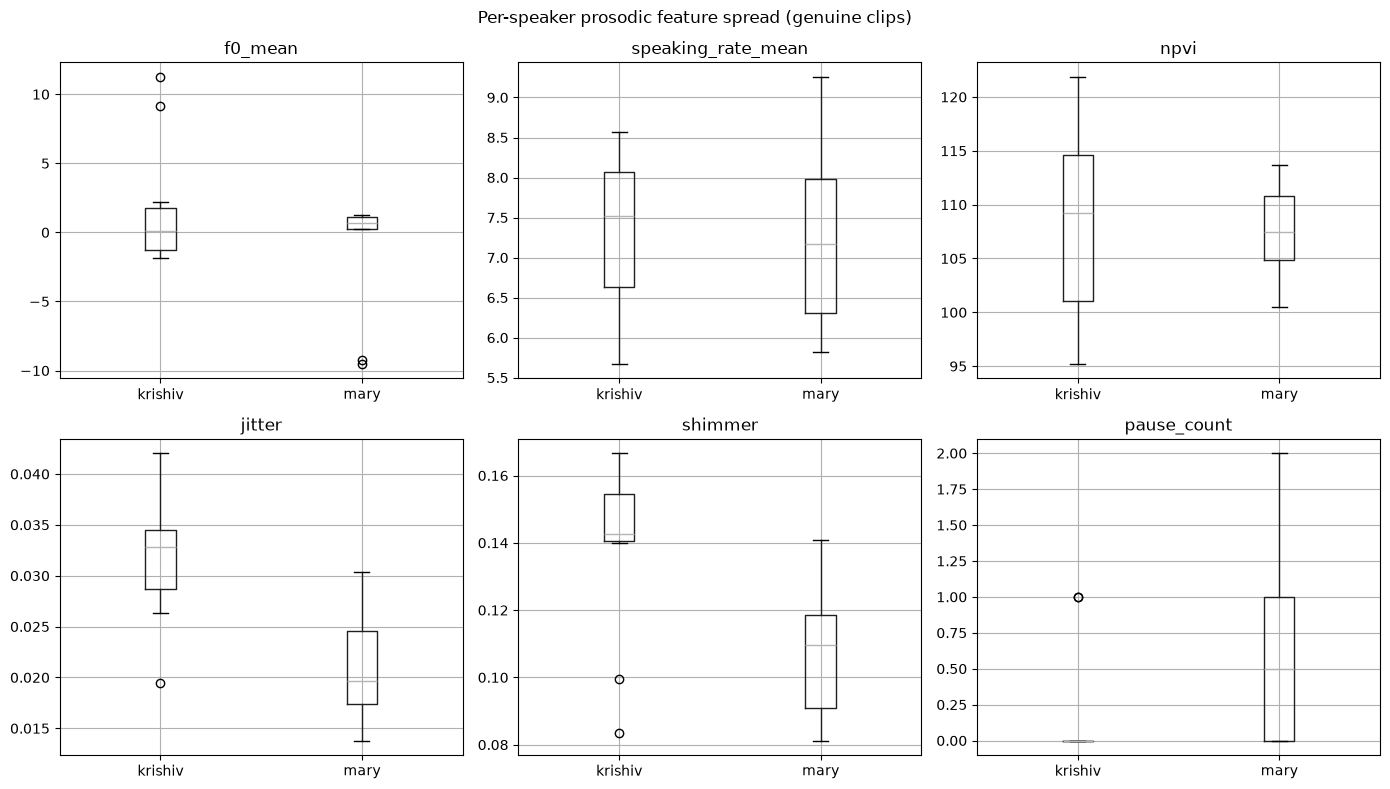

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ["f0_mean", "speaking_rate_mean", "npvi", "jitter", "shimmer", "pause_count"]
for ax, col in zip(axes.flat, plot_cols):
    genuine.boxplot(column=col, by="speaker", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Per-speaker prosodic feature spread (genuine clips)")
plt.tight_layout()
plt.show()

## Stage 5 model: leave-one-out self-consistency

No synthetic clips exist yet, so this can't measure genuine-vs-synthetic discrimination (Stage 5's actual purpose). What it *can* check: with each speaker's genuine clip held out in turn, does their own One-Class SVM (trained on the other 9) still accept it as genuine?

This is a **noisy, small-sample diagnostic**, not a target to hyperparameter-tune against (`src/models/oneclass.py` deliberately didn't grid-search nu/gamma against this same holdout — see CLAUDE.md Stage 5 notes on why RBF was dropped for a linear kernel).

In [4]:
for speaker, group in genuine.groupby("speaker"):
    acc, preds = leave_one_out_eval(speaker, group, f0_refs[speaker])
    y_true = [1] * len(preds)
    y_score = [1.0 if p == "genuine" else -1.0 for p in preds]
    metrics = evaluate(y_true, y_score)
    print(f"{speaker}: self-acceptance={acc:.0%}  {metrics}")

krishiv: self-acceptance=60%  {'accuracy': 0.6, 'precision': 1.0, 'recall': 0.6, 'f1': 0.75, 'roc_auc': nan, 'eer': nan}
mary: self-acceptance=50%  {'accuracy': 0.5, 'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666, 'roc_auc': nan, 'eer': nan}


`roc_auc` and `eer` are `nan` above — expected, since leave-one-out here only ever has genuine (positive-class) examples. Those metrics need synthetic clips as the negative class.

## Real evaluation (blocked on synthetic data)

Once `data/synthetic/<speaker>/<tts_system>/` has clones and `python src/features.py` has been re-run, this cell scores each speaker's held-out genuine clips *and* their synthetic clones against that speaker's trained model, then reports full metrics (accuracy/precision/recall/F1/ROC-AUC/EER) plus an ROC curve.

In [5]:
from sklearn.metrics import RocCurveDisplay

from oneclass import SpeakerAnomalyDetector

synthetic = df[df["label"] == "synthetic"]

if synthetic.empty:
    print("No synthetic clips in features.csv yet — nothing to evaluate. See Stage 1 in CLAUDE.md.")
else:
    for speaker in genuine["speaker"].unique():
        detector = SpeakerAnomalyDetector.load(speaker)
        speaker_genuine = genuine[genuine["speaker"] == speaker]
        speaker_synth = synthetic[synthetic["speaker"] == speaker]
        rows = pd.concat([speaker_genuine, speaker_synth])
        y_true = (rows["label"] == "genuine").astype(int).to_numpy()
        y_score = np.array([detector.score(r.to_dict())["confidence"] for _, r in rows.iterrows()])

        metrics = evaluate(y_true, y_score)
        print(f"{speaker}: {metrics}")
        RocCurveDisplay.from_predictions(y_true, y_score, name=speaker)
        plt.title(f"{speaker}: ROC curve")
        plt.show()

No synthetic clips in features.csv yet — nothing to evaluate. See Stage 1 in CLAUDE.md.
